In [1]:
import os
import sys
import time
import json
import random
import argparse
from pathlib import Path

import torch

# Repo setup
repo_root = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from argparse import Namespace
from pathlib import Path
import torch

from revlm.config_utils import configure_args
from revlm.run.edit import run_edit

editor_name = "ike_chain"


The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers and GPU quantization are unavailable.


In [ ]:
import shutil

# Map short model names to full HF model names used in results/pred/
MODEL_NAME_MAP = {
    "qwen3": "Qwen3-VL-8B-Instruct",
    "qwen3_4b": "Qwen3-VL-4B-Instruct",
    "llava": "llava-1.5-7b-hf",
    "blip": "instructblip-vicuna-7b",
}

project_root = Path(repo_root)
model_name = "qwen3_4b"       # <-- change to match your model
dataset_name = "aokvqa"        # <-- change to match your dataset

full_model_name = MODEL_NAME_MAP[model_name]
src = project_root / "results" / "pred" / full_model_name / dataset_name / "mc_all.json"
# change "results" to whatever we want to call our bias
dst_dir = project_root / "results" / "test" / f"editor_{editor_name}" / model_name / dataset_name
dst_dir.mkdir(parents=True, exist_ok=True)
dst = dst_dir / "pred_mc.json"

assert src.exists(), f"Source not found: {src}"
shutil.copy2(src, dst)
print(f"Copied {src}\n    -> {dst}")


Copied /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results/pred/Qwen3-VL-4B-Instruct/aokvqa/mc_all.json
    -> /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results_bit/test/editor_ike_chain/qwen3_4b/aokvqa/pred_mc.json


Task evaluation metrics will be saved to /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Edit evaluation metrics will be saved to /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Predictions will be saved to /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Post-edit predictions will be saved to /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa/pred_postedit
Unified filename to save: mc_all.json
Step 1 (predictions)
Total samples 18195 loaded from /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa/pred_mc.json
getting edits predicted by: label_maxprob

model_old predictions:
{'uid': '1', 'image': 'data/images/aokvqa/train2017/000000299207.jpg', 'question': 'What is the man by the bags awaiting?', 'answer

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/sgw3fy/.netrc.


created parent_dir: /home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/aux_files/subsample_edits
stored edit_ds


wandb: Currently logged in as: mgutierrezc442 (mgutierrezc442-university-of-virginia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Batch 1: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...
[Keys] +4 added, 3 merged (from 7 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 0->4 keys, 0.0 MB
Batch 2: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Keys] +8 added, 0 merged (from 8 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 4->12 keys, 0.0 MB
Batch 3: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Keys] +8 added, 0 merged (from 8 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 12->20 keys, 0.1 MB
Batch 4: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1..

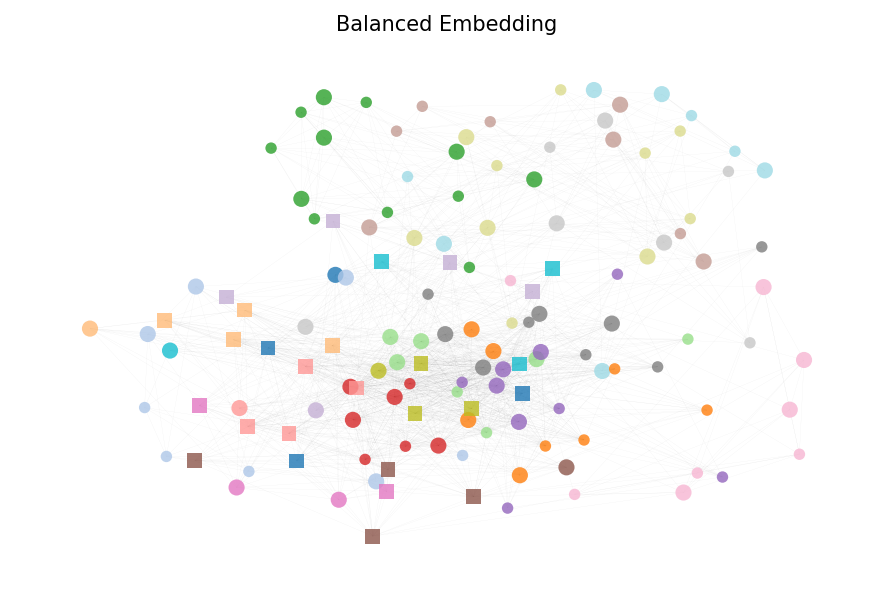

[Timing] reliability: 12.89s
Reliability: 0.9500
[IKE_CHAIN] applied facts to 100/100 examples
  [0] q='What do we call the structures at the head of the bed?' answer='finials' prompt='The image shows bed structures with tips. These ornamental tips are commonly referred to as finials. The tips of bed structures often have a specific design or ornamentation. The answer to 'What is the tip of the bed structures called?' is finials. What do we call the structures at the head of the bed?'
  [1] q='What is the term for the components located at the top of the bed?' answer='finials' prompt='The image shows bed structures with tips. These ornamental tips are commonly referred to as finials. The tips of bed structures often have a specific design or ornamentation. The answer to 'What is the tip of the bed structures called?' is finials. What is the term for the components located at the top of the bed?'
  [2] q='How are the structures at the bed's head referred to?' answer='finials' prompt='Th

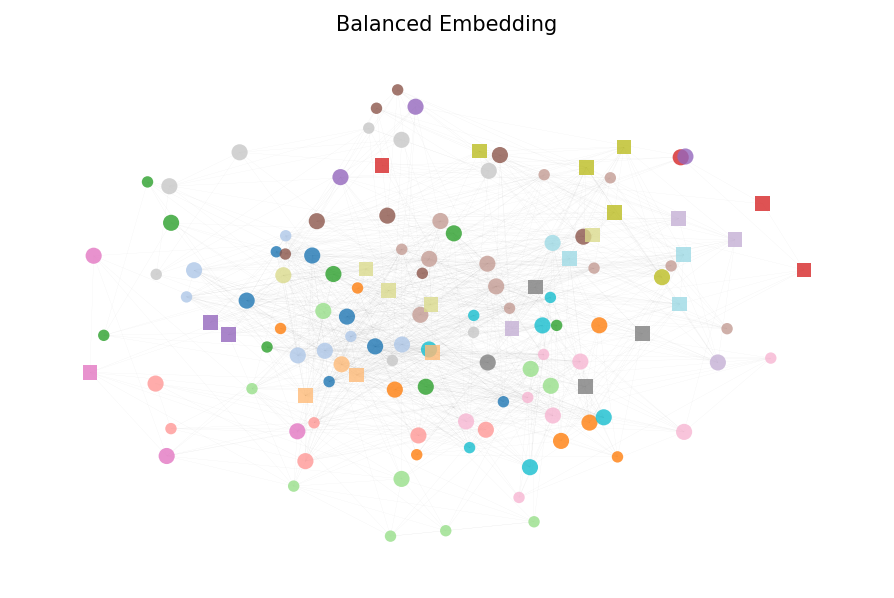

[Timing] reliability: 29.63s
Reliability: 0.9750
[IKE_CHAIN] applied facts to 200/200 examples
  [0] q='What is required to ensure the items in the pink container function properly?' answer='sharpener' prompt='The pink container holds pencils. The round things resemble beans in shape and size. Cats that live indoors are usually tame. The answer to 'What does one need to keep the items in the pink container working?' is sharpener. The image shows a pink container. A sharpener is used to keep pencils sharp. Pencils need to be kept sharp to function properly. What is required to ensure the items in the pink container function properly?'
  [1] q='What must be done to maintain the operation of the items in the pink container?' answer='sharpener' prompt='The answer to 'What is the purpose of the colorful bag?' is holding gifts. The pink container holds pencils. The round things resemble beans in shape and size. The answer to 'What does one need to keep the items in the pink container working

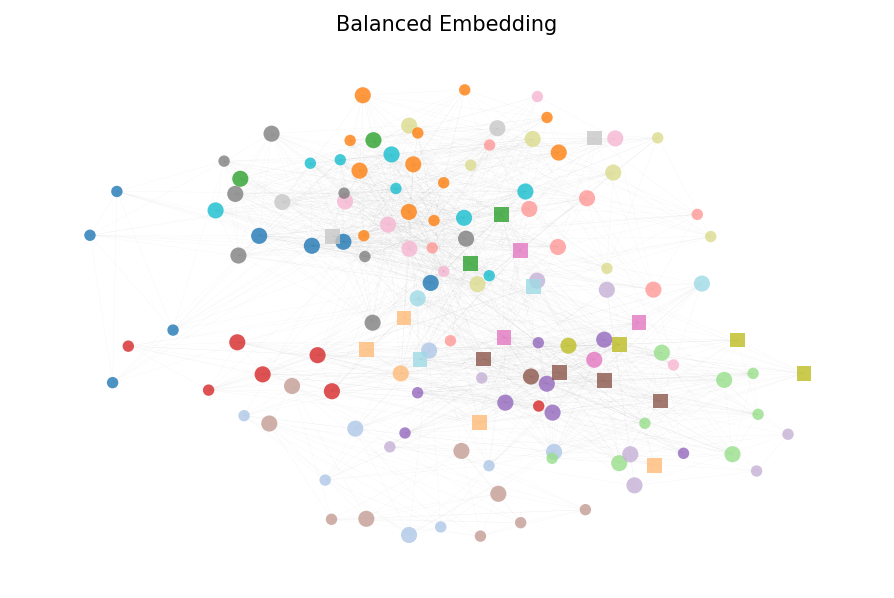

[IKE_CHAIN] applied facts to 50/50 examples
  [0] q='Why is he off the ground?' answer='intercept frisbee' prompt='The man is in the air and not touching the ground. The answer to 'To perform this trick the rider is gliding on what?' is rails. The answer to 'Why does the kneeling man crouch low?' is catch ball. The answer to 'Why is he off the ground?' is intercept frisbee. The frisbee is near the man. A person in the air near a frisbee is likely trying to catch it. The image shows a man and a frisbee. Why is he off the ground?'
  [1] q='What are the round things on the outer edge?' answer='garbanzo beans' prompt='The round things resemble beans in shape and size. The answer to 'What are the round things on the outer edge?' is garbanzo beans. The image shows round things on the outer edge. Garbanzo beans are round and similar in appearance to the objects in the image. What are the round things on the outer edge?'
  [2] q='To perform this trick the rider is gliding on what?' answer='rai

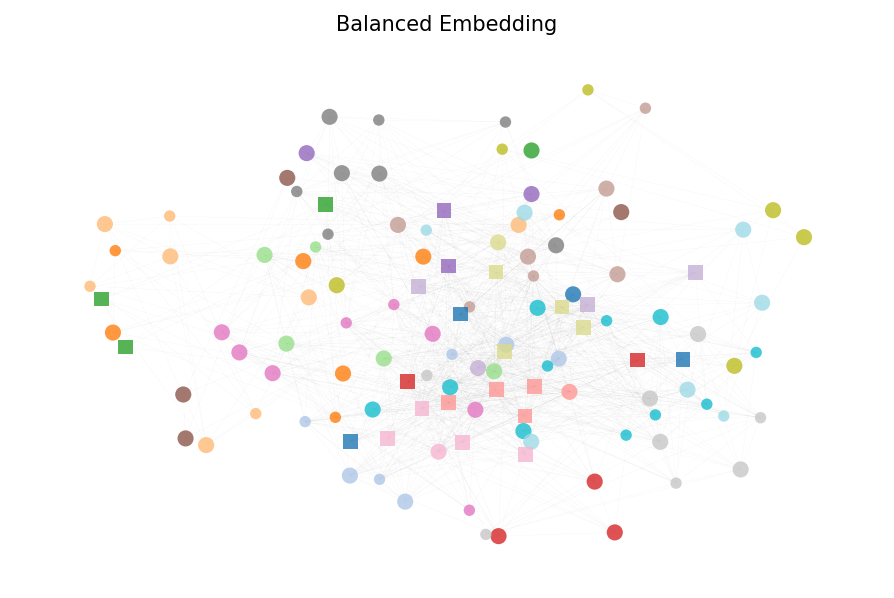

[IKE_CHAIN] applied facts to 50/50 examples
  [0] q='Where does this man?' answer='pitchers mound' prompt='The answer to 'What is the man doing?' is reading information. The man is stepping forward to throw a baseball. The man is positioned low to the ground. The answer to 'Why does the kneeling man crouch low?' is catch ball. The answer to 'Where does this man?' is pitchers mound. The man is standing on an elevated mound of sand. The image shows a man in a baseball uniform. Where does this man?'
  [1] q='Which section of the tower would light come out of to help boats?' answer='very top' prompt='The bulb that emits light is located at the top of the lighthouse. The image shows a lighthouse. Lighthouses are designed to shine light from the top to guide boats. The lighthouse has a section at the very top. The answer to 'Which section of the tower would light come out of to help boats?' is very top. Which section of the tower would light come out of to help boats?'
  [2] q='What is the p

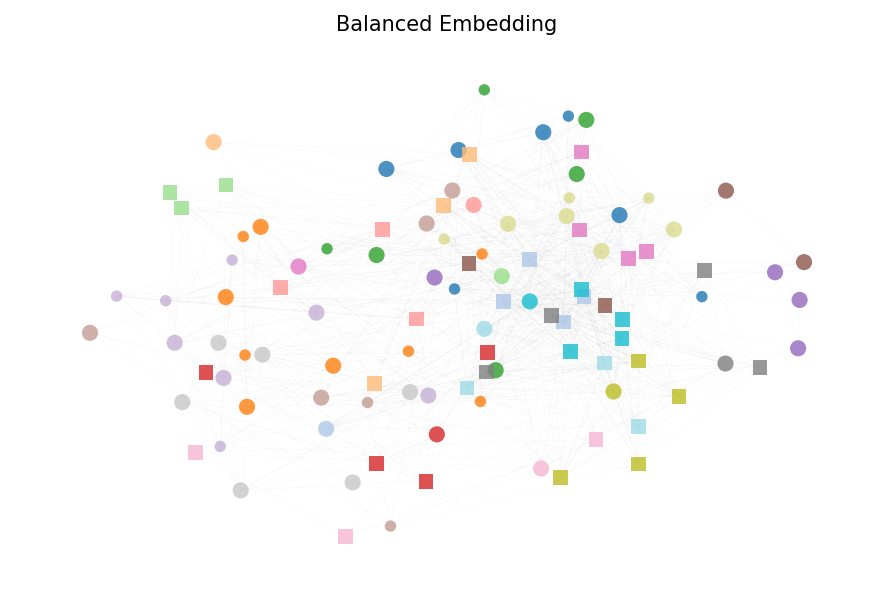

[IKE_CHAIN] applied facts to 50/50 examples
  [0] q='Where does this man?' answer='pitchers mound' prompt='The answer to 'What is the man doing?' is reading information. The man is stepping forward to throw a baseball. The man is positioned low to the ground. The answer to 'Why does the kneeling man crouch low?' is catch ball. The answer to 'Where does this man?' is pitchers mound. The man is standing on an elevated mound of sand. The image shows a man in a baseball uniform. Where does this man?'
  [1] q='Which section of the tower would light come out of to help boats?' answer='very top' prompt='The bulb that emits light is located at the top of the lighthouse. The image shows a lighthouse. Lighthouses are designed to shine light from the top to guide boats. The lighthouse has a section at the very top. The answer to 'Which section of the tower would light come out of to help boats?' is very top. Which section of the tower would light come out of to help boats?'
  [2] q='What is the p

In [ ]:

# Project root
project_root = Path(repo_root)

# Build test paths from args (no hardcoding)
args = Namespace(
    config="revlm/config/config.yaml",
    editor=editor_name,
    model_name="qwen3_4b",
    dataset_name="aokvqa",
    task="mc",
    batch_size=1,
    split="all",
    rationale=False,
    cot=False,
    subsample=0,
    subsample_edits=500,
    overwrite=True,
)

# Derive result prefix from args
res_prefix = project_root / "results" / "test" / f"editor_{args.editor}" / args.model_name / args.dataset_name
res_prefix.mkdir(parents=True, exist_ok=True)
(res_prefix / "pred_postedit").mkdir(parents=True, exist_ok=True)

# Force all outputs into the test prefix (overwrite allowed)
args.task_dir = str(res_prefix)
args.edit_dir = str(res_prefix)
args.pred_dir = str(res_prefix)
args.pred_path = str(res_prefix / "pred_mc.json")

args.pred_postedit_dir = str(res_prefix / f"pred_postedit")

args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
args.suffix = "_cot" if args.rationale and args.cot else ("_rationale" if args.rationale else "")

config = configure_args(args, config_path=args.config)
config.subsample = args.subsample
config.subsample_edits = args.subsample_edits
config.rationale = args.rationale
config.cot = args.cot
config.pred_path = args.pred_path
config.overwrite = args.overwrite
config.task_dir = args.task_dir
config.pred_dir = args.pred_dir
config.pred_postedit_dir = args.pred_postedit_dir
config.edit_dir = args.edit_dir

config.plot_k_dist = True 
run_edit(config, sequential=True, eval_every=20, subsample_path="/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/aux_files/subsample_edits/aokvqa.json")